# Pilot 2 — EDA + variance calibration

Pilot 2 is the 2-condition (verbatim vs. bullet-points), N=30 run we
use to (a) confirm the data-integrity fixes from Pilot 1 held end-to-end
and (b) get pilot estimates of the random-effect variance components
(`σ_participant`, `σ_question`) for the funded study's GLMM power
analysis.

We restrict to participants Prolific marked **APPROVED** in the
demographic export. RETURNED / TIMED-OUT submissions are excluded
from every analysis below.

In [1]:
import json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 100)

DATA = Path('../data')
LOGGING_CSV = DATA / 'pilot2-speechspectrum-study-logging - Pilot2.csv'
DEMOG_CSV   = DATA / 'pilot2-prolific_demographic_export_6a30b0639df1cab7b8cbce40.csv'

demog = pd.read_csv(DEMOG_CSV)
demog.columns = [c.strip() for c in demog.columns]
print('Demographic export status counts:')
print(demog['Status'].value_counts().to_string())

APPROVED_PIDS = set(demog.loc[demog['Status'] == 'APPROVED', 'Participant id'])
print(f'\n{len(APPROVED_PIDS)} APPROVED participants')

Demographic export status counts:
Status
APPROVED     30
RETURNED      7
TIMED-OUT     4

30 APPROVED participants


In [2]:
# Load the logging events and restrict to the APPROVED PIDs only.
raw = pd.read_csv(LOGGING_CSV)
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed:')]
raw['timestamp'] = pd.to_datetime(raw['timestamp'], errors='coerce', utc=True)
for c in ['event_type','prolific_id','assigned_condition','latin_square_order',
          'session_id','question_id','question_text','response','extra']:
    if c in raw.columns: raw[c] = raw[c].fillna('')
raw['style'] = raw['assigned_condition'].str.split(' / ').str[0]

# Drop TEST/SMOKE/dev PIDs first so they don't pollute event counts.
DEV_PREFIXES = ('TEST', 'SMOKE')
raw = raw[~raw['prolific_id'].str.upper().str.startswith(DEV_PREFIXES)].copy()

# Restrict to APPROVED participants.
df = raw[raw['prolific_id'].isin(APPROVED_PIDS)].copy()

# Sanity-check: are any APPROVED PIDs missing from the logging sheet?
# This caught a pre-PID logging gap in Pilot 1; flag explicitly here.
missing_from_logs = APPROVED_PIDS - set(df['prolific_id'])
print(f'APPROVED PIDs missing from logging sheet: {len(missing_from_logs)}')
for pid in sorted(missing_from_logs):
    print(f'  - {pid}')

n_pid = df['prolific_id'].nunique()
print(f'\n{len(df)} logged events from {n_pid} APPROVED participants '
      f'(of {len(APPROVED_PIDS)} approved)')
print('\nevent type counts:')
print(df['event_type'].value_counts().to_string())


APPROVED PIDs missing from logging sheet: 2
  - 58adfc6e7cf56d0001f931a2
  - 6a151a4fab08eb955f9294c3

3020 logged events from 28 APPROVED participants (of 30 approved)

event type counts:
event_type
question_timing              924
survey_response              896
demographic                  265
page_view                    209
post_survey                  148
question_order               116
transcript_timing            112
transcript_scroll_summary    111
page_timing                   91
study_complete                55
content_ack                   31
study_start                   31
condition_assignment          30
bug_report                     1


## 1. Assignment balance

Verify the random style + Latin-square assignment didn't end up
lopsided in this small sample.

In [3]:
def first_nonempty(series):
    s = series[series.astype(str).str.len() > 0]
    return s.iloc[0] if len(s) else ''

per_pid = (df.groupby('prolific_id')
             .agg(style=('style', first_nonempty),
                  order=('latin_square_order', first_nonempty))
             .reset_index())
per_pid = per_pid[per_pid['style'].isin(['verbatim','bullet-points'])]

print(f'{len(per_pid)} participants with a non-empty assigned style')
print('\nStyle × Latin-square cell counts:')
print(pd.crosstab(per_pid['style'], per_pid['order'], margins=True))


28 participants with a non-empty assigned style

Style × Latin-square cell counts:
order          A  B  C  D  All
style                         
bullet-points  6  3  3  5   17
verbatim       2  2  5  2   11
All            8  5  8  7   28


## 2. Completion-time sanity check

Median time end-to-end. We chose 50 minutes as the Prolific estimate
after Pilot 1; this is the check on whether that was right for Pilot 2.

28 participants with start → complete
count    28.0
mean     50.2
std      15.4
min      15.3
25%      40.1
50%      50.8
75%      60.6
max      76.3

Prolific estimate was 50 min → $15.60/hr at estimate, $15.34/hr at observed median


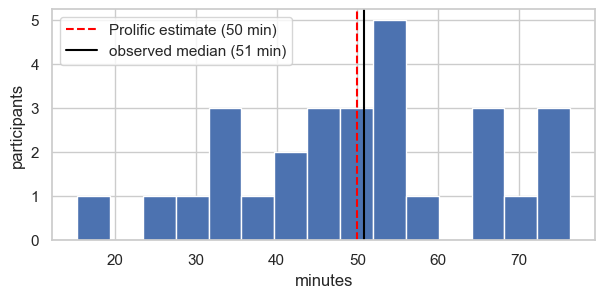

In [4]:
start = (df[df['event_type']=='study_start']
         .groupby('prolific_id')['timestamp'].min().rename('t_start'))
end   = (df[df['event_type']=='study_complete']
         .groupby('prolific_id')['timestamp'].min().rename('t_end'))
dur = pd.concat([start, end], axis=1).dropna()
dur['minutes'] = (dur['t_end'] - dur['t_start']).dt.total_seconds() / 60

print(f'{len(dur)} participants with start → complete')
print(dur['minutes'].describe().round(1).to_string())
print(f'\nProlific estimate was 50 min → ${13/(50/60):.2f}/hr at estimate, '
      f'${13/(dur["minutes"].median()/60):.2f}/hr at observed median')

fig, ax = plt.subplots(figsize=(7,3))
ax.hist(dur['minutes'], bins=15, edgecolor='white')
ax.axvline(50, color='red', ls='--', label='Prolific estimate (50 min)')
ax.axvline(dur['minutes'].median(), color='black', ls='-', label=f"observed median ({dur['minutes'].median():.0f} min)")
ax.set_xlabel('minutes')
ax.set_ylabel('participants')
ax.legend()
plt.show()

## 3. Bug reports & exit events

Quick scan for anything participants flagged. APPROVED-only, so this
is reports from participants whose submissions were still accepted.

In [5]:
bugs = df[df['event_type']=='bug_report'][['timestamp','prolific_id','style','response']]
print(f'{len(bugs)} bug reports')
if len(bugs):
    import textwrap
    for _, b in bugs.iterrows():
        print(f"\n[{b['prolific_id']} | {b['style']}]")
        for line in textwrap.wrap(str(b['response']), width=90): print(' ', line)

exits = df[df['event_type']=='study_exit'][['timestamp','prolific_id','style','extra']]
print(f'\n{len(exits)} exit-button presses from APPROVED participants (should be 0 — they completed)')
if len(exits): display(exits)

1 bug reports

[6824fd5f12b792fdaec9b2be | ]
  The transcript just dissapeard

0 exit-button presses from APPROVED participants (should be 0 — they completed)


## 4. Comprehension accuracy

Letter-based scoring. We derive the letter (A–E) the participant
clicked from their saved response, then compare against the answer
key in `docs/questions.js`.

In [6]:
qjs = Path('../docs/questions.js').read_text(encoding='utf-8')
m = re.search(r'QUESTIONS_BY_TRANSCRIPT\s*=\s*(\{.*?\});', qjs, re.S)
QBT = json.loads(m.group(1))

E_OPTION = 'This interaction is not shown in the transcript / Not enough information to answer this question'
LETTERS = ['A','B','C','D','E']

qid_options, qid_correct_letter, qid_level = {}, {}, {}
for tkey, qs in QBT.items():
    for q in qs:
        qid_options[q['id']] = list(q.get('options') or []) + [E_OPTION]
        if q.get('correct_letter'): qid_correct_letter[q['id']] = q['correct_letter']
        if q.get('level'):          qid_level[q['id']]          = q['level']
print(f'{len(qid_correct_letter)} keyed questions across {len(QBT)} transcripts')

# Pilot 2 stores values prefixed with "A) ..." / "E) ..." — the letter is the
# first char inside the attribute. We still fall back to text-match for
# safety (handles any legacy rows that snuck in).
PREFIX_RE = re.compile(r'^([A-E])\)\s')
def derive_letter(response, options):
    resp = str(response).strip()
    if not resp: return None
    m = PREFIX_RE.match(resp)
    if m: return m.group(1)
    for i, opt in enumerate(options):
        if resp == opt.strip(): return LETTERS[i]
    hits = [i for i, opt in enumerate(options) if opt.startswith(resp)]
    return LETTERS[hits[0]] if len(hits)==1 else None

sr = df[df['event_type']=='survey_response'].copy()
sr['chosen_letter']  = sr.apply(lambda r: derive_letter(r['response'], qid_options.get(r['question_id'], [])), axis=1)
sr['correct_letter'] = sr['question_id'].map(qid_correct_letter)
sr['level']          = sr['question_id'].map(qid_level)
sr['correct']        = (sr['chosen_letter'] == sr['correct_letter']).where(sr['chosen_letter'].notna() & sr['correct_letter'].notna())
scored = sr.dropna(subset=['correct']).copy()
scored['correct'] = scored['correct'].astype(int)

print(f'\n{len(sr)} survey_response rows → {len(scored)} scored')
print('chosen-letter distribution:')
print(scored['chosen_letter'].value_counts().reindex(LETTERS, fill_value=0).to_string())

32 keyed questions across 4 transcripts

896 survey_response rows → 896 scored
chosen-letter distribution:
chosen_letter
A    100
B    197
C    251
D     77
E    271


In [7]:
# Overall accuracy by condition
by_cond = (scored.groupby('style')['correct'].agg(['mean','count'])
           .rename(columns={'mean':'accuracy','count':'n_trials'}))
by_cond['accuracy'] = by_cond['accuracy'].round(3)
print('Accuracy by condition (all questions, all levels):')
print(by_cond.to_string())

# Accuracy by condition × level
by_cl = (scored.groupby(['style','level'])['correct']
         .agg(['mean','count'])
         .rename(columns={'mean':'accuracy','count':'n'}))
by_cl['accuracy'] = by_cl['accuracy'].round(3)
print('\nAccuracy by condition × level:')
print(by_cl.to_string())

Accuracy by condition (all questions, all levels):
               accuracy  n_trials
style                            
bullet-points     0.349       544
verbatim          0.739       352

Accuracy by condition × level:
                     accuracy    n
style         level               
bullet-points L1        0.434  136
              L2        0.309  136
              L3        0.309  136
              L4        0.346  136
verbatim      L1        0.852   88
              L2        0.784   88
              L3        0.648   88
              L4        0.670   88


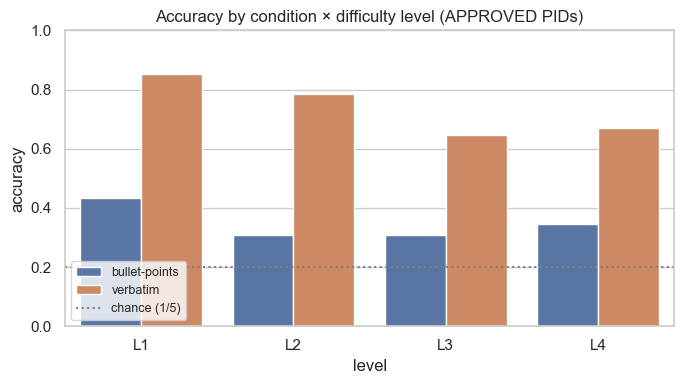


Per-question accuracy (sorted ascending) — floor/ceiling questions:
             accuracy   n
question_id              
TranscrA_q6     0.107  28
TranscrA_q7     0.286  28
TranscrC_q6     0.321  28
TranscrB_q7     0.321  28
TranscrA_q8     0.321  28
...
             accuracy   n
question_id              
TranscrD_q8     0.714  28
TranscrD_q7     0.714  28
TranscrC_q1     0.750  28
TranscrB_q1     0.821  28
TranscrA_q1     0.893  28


In [8]:
# Plot: condition × level accuracy
plot_df = (scored.groupby(['style','level'])['correct']
           .mean().reset_index(name='accuracy'))
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(plot_df, x='level', y='accuracy', hue='style', ax=ax,
            order=['L1','L2','L3','L4'])
ax.set_ylim(0,1)
ax.axhline(0.2, ls=':', color='gray', label='chance (1/5)')
ax.set_title('Accuracy by condition × difficulty level (APPROVED PIDs)')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

# Per-question hit rate — surfaces any broken question (near 0 or 1 across both conditions)
per_q = (scored.groupby('question_id')['correct']
         .agg(['mean','count'])
         .rename(columns={'mean':'accuracy','count':'n'})
         .sort_values('accuracy'))
per_q['accuracy'] = per_q['accuracy'].round(3)
print('\nPer-question accuracy (sorted ascending) — floor/ceiling questions:')
print(per_q.head(5).to_string())
print('...')
print(per_q.tail(5).to_string())

## 5. Highlighting behavior

Per-participant highlighting intensity by condition. Validates that
highlighting was used (and that fewer highlights show up on ‘E)’ answers,
since E doesn’t require evidence).

Mean / median highlights per response, by condition × chosen letter:
                             mean  median
style         chosen_letter              
bullet-points A              1.42     1.0
              B              1.32     1.0
              C              1.35     1.0
              D              1.51     1.0
              E              0.56     0.0
verbatim      A              2.00     1.0
              B              1.96     1.0
              C              2.24     1.0
              D              1.70     1.0
              E              0.25     0.0


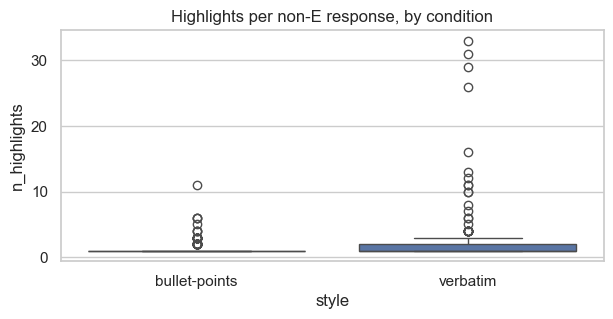

In [9]:
def n_highlights(extra):
    try:
        d = json.loads(extra) if extra else {}
        return len((d.get('highlights') or []))
    except Exception:
        return 0

scored['n_highlights'] = scored['extra'].apply(n_highlights)
hl = (scored.groupby(['style','chosen_letter'])['n_highlights']
      .agg(['mean','median']).round(2))
print('Mean / median highlights per response, by condition × chosen letter:')
print(hl.to_string())

fig, ax = plt.subplots(figsize=(7,3))
sns.boxplot(scored[scored['chosen_letter']!='E'], x='style', y='n_highlights', ax=ax)
ax.set_title('Highlights per non-E response, by condition'); plt.show()

## 6. Variance components for the funded-study power analysis

The funded study will be analyzed with

```
correct ~ condition * level + (1 | participant) + (1 | question)
```

Power for that model is dominated by the two random-intercept SDs
(`σ_participant`, `σ_question`). We fit the model on Pilot 2 data
(2 conditions, but the random-intercept variances are pooled across
all participants / all questions, so the estimate is valid for
feeding into a simulation-based power analysis for the 4-condition
funded study).

We fit a binomial mixed-effects GLM via `statsmodels`. If `pymer4`
(lme4 via rpy2) is available the next-to-last cell shows how to fit
the same model there — lme4’s Laplace approximation is the standard.

In [10]:
# Build the modeling frame: one row per scored trial.
mdf = scored[['prolific_id','question_id','style','level','correct']].copy()
mdf = mdf.rename(columns={'prolific_id':'participant'})
print(f'{len(mdf)} trials | '
      f'{mdf["participant"].nunique()} participants | '
      f'{mdf["question_id"].nunique()} questions')

# --- Fit with statsmodels BinomialBayesMixedGLM (variational Bayes). ---
# Slow on first call but always available.
import statsmodels.api as sm
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

X_cols = ['style','level']
X = pd.get_dummies(mdf[X_cols], drop_first=True).astype(float)
X = sm.add_constant(X)
# Interaction terms
for s_col in [c for c in X.columns if c.startswith('style_')]:
    for l_col in [c for c in X.columns if c.startswith('level_')]:
        X[f'{s_col}:{l_col}'] = X[s_col] * X[l_col]

# Random-effect design matrices (one per group factor)
p_dummies = pd.get_dummies(mdf['participant']).astype(float)
q_dummies = pd.get_dummies(mdf['question_id']).astype(float)
exog_vc = {'participant': p_dummies, 'question': q_dummies}
ident   = np.array([0]*p_dummies.shape[1] + [1]*q_dummies.shape[1])
vc_mat  = pd.concat([p_dummies, q_dummies], axis=1).values

model = BinomialBayesMixedGLM(
    endog=mdf['correct'].values,
    exog=X.values,
    exog_vc=vc_mat,
    ident=ident,
    vcp_p=3,  # weakly informative prior on the random-effect SDs
)
result = model.fit_vb()

vc_sd = np.exp(result.vcp_mean)  # vcp is on log-SD scale
sigma_participant, sigma_question = vc_sd[0], vc_sd[1]
print(f'\nσ_participant (logit scale) ≈ {sigma_participant:.3f}')
print(f'σ_question    (logit scale) ≈ {sigma_question:.3f}')
print('\nUse these as the random-intercept SDs in your funded-study simulation.')
print('Apply ~20% upward inflation for conservatism (Albers & Lakens 2018).')

896 trials | 28 participants | 32 questions

σ_participant (logit scale) ≈ 1.319
σ_question    (logit scale) ≈ 0.949

Use these as the random-intercept SDs in your funded-study simulation.
Apply ~20% upward inflation for conservatism (Albers & Lakens 2018).


In [11]:
# Sanity proxies for the variance components, computed without a model fit.
# These are biased low (binomial trial-level noise leaks into the empirical SDs),
# but they're a cross-check that the model fit is in the right ballpark.
from scipy.special import logit as _logit

def safe_logit(p, n, eps=0.5):
    p = (p*n + eps) / (n + 2*eps)
    return _logit(p)

p_acc = scored.groupby('prolific_id')['correct'].agg(['mean','count'])
q_acc = scored.groupby('question_id')['correct'].agg(['mean','count'])
sd_p_proxy = safe_logit(p_acc['mean'], p_acc['count']).std()
sd_q_proxy = safe_logit(q_acc['mean'], q_acc['count']).std()
print(f'sanity proxies (logit-scale SDs across cell means, biased low):')
print(f'  σ_participant proxy ≈ {sd_p_proxy:.3f}  '
      f'(across {len(p_acc)} participants)')
print(f'  σ_question    proxy ≈ {sd_q_proxy:.3f}  '
      f'(across {len(q_acc)} questions)')
print('The model fit above should report SDs at least as large as these.')

sanity proxies (logit-scale SDs across cell means, biased low):
  σ_participant proxy ≈ 1.500  (across 28 participants)
  σ_question    proxy ≈ 0.755  (across 32 questions)
The model fit above should report SDs at least as large as these.


In [12]:
# Optional: same model in lme4 via pymer4. Skip if not installed.
try:
    from pymer4.models import Lmer
    m = Lmer('correct ~ style * level + (1|participant) + (1|question_id)',
             data=mdf, family='binomial')
    m.fit(summarize=False)
    print('lme4 fixed effects:'); print(m.coefs)
    print('\nlme4 random-effect SDs:'); print(m.ranef_var)
except Exception as e:
    print(f'pymer4 not used ({type(e).__name__}: {e})')
    print('Skip if you have what you need from the statsmodels fit.')

pymer4 not used (ModuleNotFoundError: No module named 'pymer4')
Skip if you have what you need from the statsmodels fit.


## What to take into the power simulation

From this notebook, plug into your `simr`/`simglm` script:

1. **`σ_participant`** and **`σ_question`** — from the model fit above.
   Inflate ~20% for conservatism.
2. **Trial structure** — 32 trials/participant, 4 transcripts × 8 Qs,
   stratified by level (L1–L4, 2 Qs each).
3. **Latin-square assignment** — 4 orderings, uniform random.
4. **Fixed-effect SESOI** — specify by hand, *not* from Pilot 2.
   The 2-condition design gives you no leverage on the
   condition × level interaction; only random-effect variance is
   transferable to the 4-condition funded study.